# EDA Notebook

We will use this notebook to evaluate and process our data from the CSV files.

In [3]:
print("Hello, Vibetastrophe Consulting!")

Hello, Vibetastrophe Consulting!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Import CSV files into pandas

We will import the csv from the `data/raw/smart_city_csvs` folder.

In [5]:
#load the data
city_df = pd.read_csv('../data/raw/smart_city_csvs/city_traffic_accidents.csv')

urban_df = pd.read_csv('../data/raw/smart_city_csvs/urbanpulse_311_complaints.csv')

In [6]:
city_df.head(10)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1784167,Source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-862811,Source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-4054572,Source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,33.535373,-86.796156,0.152,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-6147589,Source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,34.078917,-117.625339,0.869,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-5025169,Source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,40.322625,-76.788114,0.166,...,False,False,False,False,False,False,Day,Day,Day,Day
5,A-4007360,Source1,2,2022-11-16 05:22:30.000000,2022-11-16 08:04:30.000000,34.024005,-117.557851,34.029942,-117.579011,1.279,...,False,False,False,False,False,False,Night,Night,Night,Day
6,A-2185422,Source2,2,2019-04-24 07:25:21,2019-04-24 08:25:01,34.136070,-80.880547,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
7,A-94012,Source2,2,2016-08-31 11:14:13,2016-08-31 11:44:13,34.245651,-118.874870,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-6717568,Source1,2,2020-10-24 20:15:00,2020-10-24 22:19:12,38.671507,-120.566459,38.671875,-120.566081,0.033,...,False,False,False,False,False,False,Night,Night,Night,Night
9,A-2960129,Source2,2,2018-03-21 20:44:14,2018-03-21 21:14:06,30.413244,-97.690582,NaN,NaN,0.000,...,False,False,False,False,True,False,Night,Night,Night,Day


In [7]:
urban_df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
5,68173650,2026-03-01T13:18:50.000,2026-03-01T13:41:16.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,ONLINE,Closed
6,67996182,2026-02-14T04:34:09.000,2026-02-14T07:30:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
7,67989111,2026-02-13T13:14:39.000,2026-02-15T21:30:43.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,This complaint is a duplicate of a building-wi...,QUEENS,ONLINE,Closed
8,68284021,2026-03-10T08:15:03.000,2026-03-11T14:26:55.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
9,67918125,2026-02-09T11:41:22.000,NaN,DOHMH,Department of Health and Mental Hygiene,Non-Residential Heat,Inadequate or No Heat,The Department of Health and Mental Hygiene ha...,BRONX,ONLINE,In Progress


In [8]:
# Seeing how many missing values there are in each column
missing_values_city = city_df.isnull().sum()
missing_values_urban = urban_df.isnull().sum()
print("Missing values in city_df:")
print(missing_values_city)
print("\nMissing values in urban_df:")
print(missing_values_urban)


Missing values in city_df:
ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  219978
End_Lng                  219978
Distance(mi)                  0
Description                   0
Street                      654
City                         28
County                        0
State                         0
Zipcode                     118
Country                       0
Timezone                    476
Airport_Code               1514
Weather_Timestamp          7842
Temperature(F)            10700
Wind_Chill(F)            129188
Humidity(%)               11371
Pressure(in)               9170
Visibility(mi)            11482
Wind_Direction            11382
Wind_Speed(mph)           36902
Precipitation(in)        142366
Weather_Condition         11300
Amenity                       0
Bump         

In [13]:
# df.info()
city_df.info()
urban_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                280022 non-null  float64
 8   End_Lng                280022 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            500000 non-null  object 
 11  Street                 499346 non-null  object 
 12  City                   499972 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

In [14]:
# Checking for duplicates
duplicates_city = city_df.duplicated().sum()
duplicates_urban = urban_df.duplicated().sum()
print(f"Number of duplicate rows in city_df: {duplicates_city}")
print(f"Number of duplicate rows in urban_df: {duplicates_urban}")


Number of duplicate rows in city_df: 0
Number of duplicate rows in urban_df: 0


In [15]:
# checking the dtypes
print("Data types in city_df:")
print(city_df.dtypes)
print("\nData types in urban_df:")
print(urban_df.dtypes)


Data types in city_df:
ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity             

In [22]:
# Running the df.describe on both CSVs to get a statistical summary of the data
print("Statistical summary of city_df:")
print(city_df.describe())



Statistical summary of city_df:
            Severity      Start_Lat      Start_Lng        End_Lat  \
count  500000.000000  500000.000000  500000.000000  280022.000000   
mean        2.212386      36.205450     -94.706816      36.269349   
std         0.487531       5.076753      17.383787       5.269770   
min         1.000000      24.555269    -124.497585      24.571240   
25%         2.000000      33.400517    -117.217072      33.461970   
50%         2.000000      35.831195     -87.792388      36.191048   
75%         2.000000      40.081910     -80.351962      40.176147   
max         4.000000      48.993996     -67.113167      48.995141   

             End_Lng   Distance(mi)  Temperature(F)  Wind_Chill(F)  \
count  280022.000000  500000.000000   489300.000000  370812.000000   
mean      -95.712652       0.558359       61.657263      58.223946   
std        18.096908       1.719821       19.013075      22.385876   
min      -124.497421       0.000000      -89.000000     -89.000000

In [23]:
print("\nStatistical summary of urban_df:")
print(urban_df.describe())


Statistical summary of urban_df:
         unique_key
count  4.347220e+05
mean   6.808396e+07
std    1.547138e+05
min    6.780378e+07
25%    6.794857e+07
50%    6.808820e+07
75%    6.821571e+07
max    6.835334e+07


In [24]:
# Running the df.shape on both CSVs to see the number of rows and columns in each dataset
print(f"Shape of city_df: {city_df.shape}")
print(f"Shape of urban_df: {urban_df.shape}")


Shape of city_df: (500000, 46)
Shape of urban_df: (434722, 11)


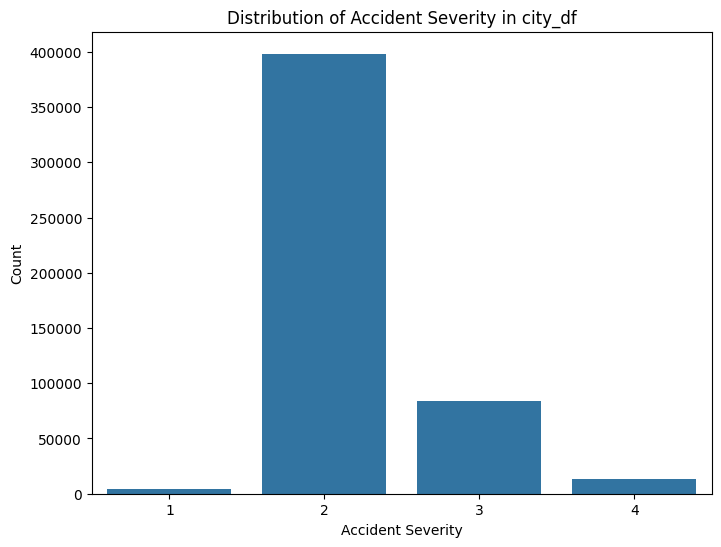

In [26]:
# plotting target variable distribution for city_df
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity', data=city_df)
plt.title('Distribution of Accident Severity in city_df')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()


In [30]:
# Checking for Class Imbalance in the target variable 'Severity' in city_df
severity_counts = city_df['Severity'].value_counts()
print("Counts of each class in 'Severity':")
print(severity_counts)


Counts of each class in 'Severity':
Severity
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64


In [31]:
# Correlation heat map for city_df
plt.figure(figsize=(10, 8))
sns.heatmap(city_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for city_df')
plt.show()


ValueError: could not convert string to float: 'A-1784167'

<Figure size 1000x800 with 0 Axes>